### Picard method

The simplest method to solve:

$$
    x = f(x)
$$

Is given by the Picard algorithm:

$$
    x_{j + 1} = f(x_{j})
$$

This method may not work sometimes. Let's test it solving the Archimede equation, looking only for positive values:

$$
    x^{3} - 3 \, x^{2} + 1 = 0
$$

This can be written as:

$$
    x = 3 - \frac{1}{x^{2}}; \quad x = \frac{1}{3} \, \left( x^{2} + \frac{1}{x} \right); \quad x = x^{3} - 3 \, x^{2} + x + 1
$$

The equation has 1 negative solution and 2 positive solutions $\alpha$ and $\beta$:

$$
    \alpha \approx 0.6527; \quad \beta \approx 2.8794
$$

In [ ]:
# Libraries and tools
import numpy as np
from scipy.optimize import newton

import matplotlib.pyplot as plt
plt.style.use('classic')

In [2]:
def f_1(x): # f(x) = 3 - 1/x^2
    return 3.0 - 1.0 / (x ** 2)

def f_2(x): # f(x) = 1/3 (x^2 + 1/x)
    return 1.0 / 3.0 * (x ** 2 + 1 / x)

def f_3(x): # f(x) = x^3 -3x^2 + x +1
    return x ** 3 - 3 * x ** 2 + x + 1

In [3]:
def picard(f, x0, N, eps): # Picard algorithm (basic implementation)

    x = x0
    x_array = [x0]
    diff_array = []

    for j in range(N):

        fx = f(x)
        diff = abs(fx - x) # Not the absolute error! See below...
        diff_array.append(diff)

        if diff < eps: # Arrest criterion
            print(f"Loop ended at j = {j}")
            break
        else:
            x = fx
            x_array.append(x)

        if j == (N - 1): print("Loop ended: maximum number of iterations reached")

    return np.array(x_array), np.array(diff_array)

# ---------------------------------------------------

def plot_picard(x_array, diff_array): # Plot function
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True)
    ax1.plot(x_array, 'o-', color = 'blue')
    ax1.set_ylabel('x')
    ax1.grid(True)
    ax2.plot(diff_array, 's-', color = 'red')
    ax2.set_ylabel('|f(x)-x|')
    ax2.set_xlabel('Iteration')
    ax2.grid(True)
    fig.suptitle('Picard iteration behaviour', fontsize = 14)
    plt.show()

In [4]:
N = 50 # Maximum number of iterations
x0 = 0.35 # Starting point
eps = 1e-06 # Tolerance

In [5]:
x, diff = picard(f_1, x0, N, eps) # Let's start with f_1(x)
x, diff

Loop ended at j = 7


(array([ 0.35      , -5.16326531,  2.96248965,  2.88605735,  2.87994228,
         2.8794319 ,  2.87938915,  2.87938557]),
 array([5.51326531e+00, 8.12575496e+00, 7.64323001e-02, 6.11506836e-03,
        5.10385638e-04, 4.27457115e-05, 3.58106153e-06, 3.00013984e-07]))

In [6]:
x[-1] # Final value

np.float64(2.8793855690186825)

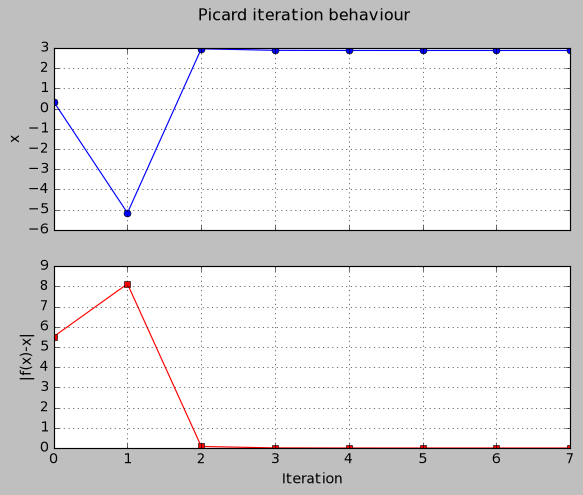

In [7]:
plot_picard(x, diff)

$f_1(x)$ yields always $\beta$ and skips $\alpha$

In [8]:
x, diff = picard(f_2, x0, N, eps) # Let's plug f_2(x)
x, diff

Loop ended at j = 12


(array([0.35      , 0.99321429, 0.66443556, 0.64883715, 0.65406947,
        0.65223215, 0.65286773, 0.6526467 , 0.65272343, 0.65269677,
        0.65270603, 0.65270282, 0.65270393]),
 array([6.43214286e-01, 3.28778722e-01, 1.55984120e-02, 5.23232254e-03,
        1.83732428e-03, 6.35583385e-04, 2.21035336e-04, 7.67284915e-05,
        2.66518946e-05, 9.25557863e-06, 3.21449231e-06, 1.11637379e-06,
        3.87713474e-07]))

In [9]:
x[-1] # Final value

np.float64(0.6527039324377195)

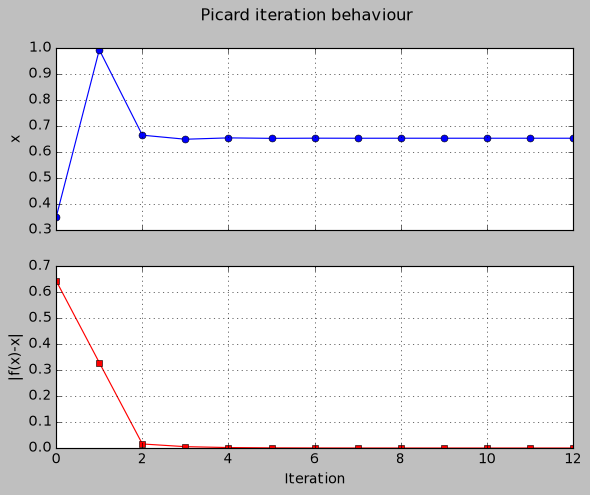

In [10]:
plot_picard(x, diff)

$f_2(x)$ yields always $\alpha$ and skips $\beta$

In [11]:
x, diff = picard(f_3, x0, N, eps) # Finally let's plug f_3(x)
x, diff

Loop ended: maximum number of iterations reached


(array([ 0.35      ,  1.025375  , -0.05073366,  0.94141404,  0.11697083,
         1.07752472, -0.15458351,  0.77003437,  0.44776972,  0.93605336,
         0.12763179,  1.08084127, -0.16115422,  0.75674844,  0.4721096 ,
         0.90867449,  0.18188934,  1.08865572, -0.17661462,  0.72429811,
         0.53044726,  0.83557859,  0.32439778,  1.04283367, -0.08558876,
         0.89180796,  0.21511763,  1.08624554, -0.17184957,  0.73447851,
         0.51232328,  0.85936998,  0.27847883,  1.06742361, -0.13454072,
         0.80872031,  0.37556086,  1.00539433, -0.0107885 ,  0.98886107,
         0.02227647,  1.02079881, -0.04158861,  0.95315062,  0.09359594,
         1.06813526, -0.1359542 ,  0.80608224,  0.38054341,  1.00121129,
        -0.00242258]),
 array([0.675375  , 1.07610866, 0.9921477 , 0.82444321, 0.96055389,
        1.23210823, 0.92461788, 0.32226465, 0.48828364, 0.80842158,
        0.95320949, 1.2419955 , 0.91790266, 0.28463884, 0.43656488,
        0.72678515, 0.90676639, 1.26527035,

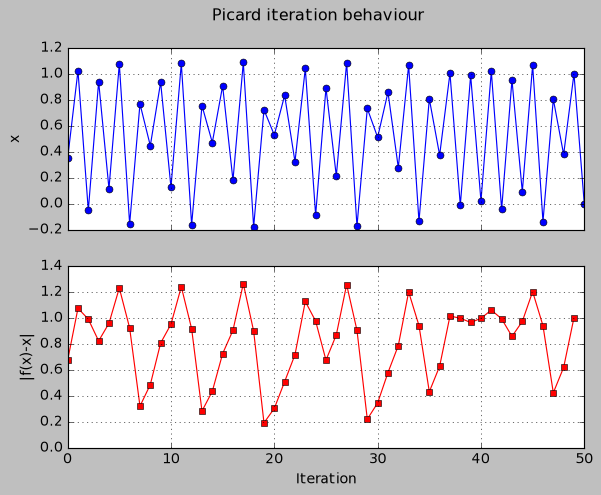

In [12]:
plot_picard(x, diff)

$f_3(x)$ doesn't work

To establish convergence, we invoke the Banach fixed-point theorem. Consider the Picard iteration:

$$
    x_{j + 1} = f(x_j)
$$

Convergence to a unique fixed point $\chi$ is guaranteed if there exists a closed interval $[a, b]$ satisfying the following two sufficient conditions:

1. Invariance: $f(x)$ maps the interval into itself:
   $$
        f(x) \in [a, b] \quad \text{for all } x \in [a, b]
   $$

2. Contraction: $f$ is a contraction on $[a, b]$:
   $$
        \sup_{x \in [a,b]} |f'(x)| < 1
   $$

Under these conditions, the fixed point $\chi$ belongs to $[a,b]$ and is unique. Moreover, for any initial guess $x_0 \in [a,b]$, the sequence $x_{j}$ converges to $\chi$.

The quantity:

$$
   \sup_{x \in [a,b]} |f'(x)|
$$

Is well-known as $L$. $g(x)$ must be a contraction on $[a, b]$ or the Picard method is divergent and does not work though.

$L$ is useful for estimating an upper bound of the error committed. If we define the absolute error as $E_k = | x_k - \chi |$, we can estimate an upper bound for $E_k$ as:

$$
   E_{k + 1} \leq \frac{L}{1 - L} \, \left| x_k - x_{k - 1} \right|
$$

Or:

$$
   E_k \leq \frac{1}{1 - L} \, \left| x_{k + 1} - x_{k} \right|
$$

Why $f_3(x)$ is unstable? Let's plot its derivative with respect to $x$:

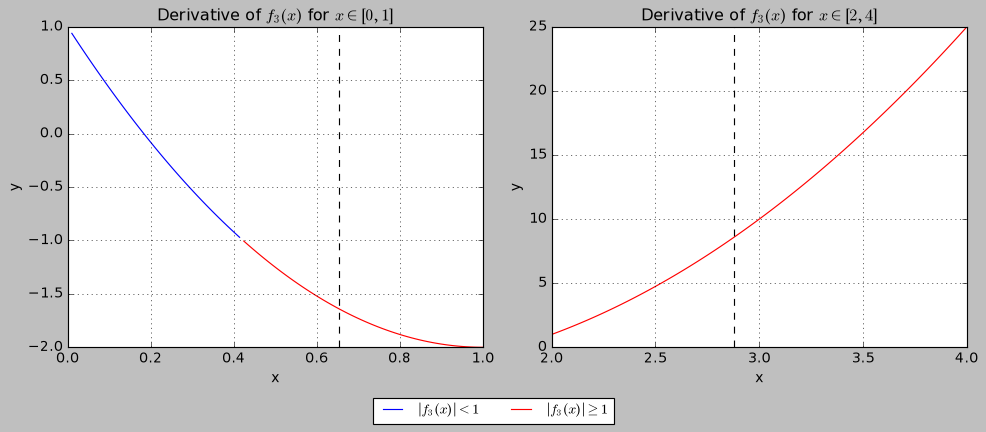

In [13]:
alpha, beta = 0.6527, 2.8794

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

xx1 = np.linspace(0, 1.0, 100)
y1 = 3 * xx1 ** 2 - 6 * xx1 + 1

y_blue1 = np.where(np.abs(y1) < 1.0, y1, np.nan)
y_red1  = np.where(np.abs(y1) >= 1.0, y1, np.nan)

ax1.set_title(r'Derivative of $f_3(x)$ for $x \in [0, 1]$', fontsize = 14)
line1_blue, = ax1.plot(xx1, y_blue1, 'b-', label=r'$|f_3(x)| < 1$')
line1_red,  = ax1.plot(xx1, y_red1,  'r-', label=r'$|f_3(x)| \geq 1$')
ax1.axvline(alpha, color = 'black', linestyle = '--')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True)

xx2 = np.linspace(2.0, 4.0, 100)
y2 = 3 * xx2 ** 2 - 6 * xx2 + 1

y_blue2 = np.where(np.abs(y2) < 1.0, y2, np.nan)
y_red2  = np.where(np.abs(y2) >= 1.0, y2, np.nan)

ax2.set_title(r'Derivative of $f_3(x)$ for $x \in [2, 4]$', fontsize = 14)
ax2.plot(xx2, y_blue2, 'b-', label = r'$|f_3(x)| < 1$')
ax2.plot(xx2, y_red2,  'r-', label = r'$|f_3(x)| \geq 1$')
ax2.axvline(beta, color = 'black', linestyle = '--')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True)

handles = [line1_blue, line1_red]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.05), ncol = 2, fontsize = 12, frameon = True)

plt.tight_layout()
plt.subplots_adjust(bottom = 0.15)
plt.show()

As you can see, the absolute value of the derivative of $f_3(x)$ with respect to x can be greater than 1 within any interval containing $\alpha$. So, Picard succession cannot converge towards $\alpha$. Same observation for $\beta$

Given $f_1(x)$, let's compute $L$.

The derivative of the function with respect to $x$ is:

$$
    f_{1}'(x) = \frac{2}{x^3}
$$

$L$ depends on the choice of the interval $[a, b]$

In [14]:
f_prime = lambda x: 2.0 / (x ** 3) # Derivative of f_1(x)

In [ ]:
def picard(f, f_prime, N, eps, a, b, n_grid = 50): # Full implementation with error bound

    # Finding L
    grid = np.linspace(a, b, n_grid) # n_grid points in [a, b]
    L = np.max(np.abs(f_prime(grid))) # L estimation

    if L >= 1.0: # L must be less than 1
        raise ValueError(f"Contraction constant L = {L} must be < 1")

    x = (a + b) / 2 # Initial value is the midpoint of [a, b]
    for j in range(N):
        fx = f(x)
        diff = abs(fx - x) # |x_{k + 1} - x_k|
        err = diff / (1.0 - L) # error bound

        if err < eps: # Now we use the upper bound error as stopping criterion
            print(f"Loop terminated at j = {j}. Error under the threshold")
            
            return x, err, L

        x = fx

    # Maximum iterations reached: recompute residual for returned x
    print(f"Loop terminated at j = {N - 1}. Maximum number of iterations reached")
    fx = f(x)
    diff = abs(fx - x)
    err = diff / (1.0 - L)

    return x, err, L

In [16]:
# Test with f_1(x)
picard(
    f = f_1,
    f_prime = f_prime,
    N = 30,
    eps = 1e-12,
    a = beta - 0.5,
    b = beta + 0.5
)

Loop terminated at j = 7. Error under the threshold


(2.8793852415722445,
 np.float64(4.60499368530936e-13),
 np.float64(0.14846621060836002))

Result:

$$
    \chi = 2.8793852415722 \pm 0.0000000000005
$$

In [17]:
scipy = newton( # Test using newtown from Scipy
    func = lambda x: f_1(x) - x,
    x0 = beta,
    fprime = lambda x: f_prime(x) - 1.0,
    tol = 1e-12
)

print(f"Scipy result = {scipy:.13f}")

Scipy result = 2.8793852415718
